# Tree-Based Survival Models
Comprehensive Notebook

In [2]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.inspection import PartialDependenceDisplay
from sklearn.inspection import permutation_importance

from sksurv.util import Surv
from sksurv.ensemble import RandomSurvivalForest
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored

from xgboost import XGBRegressor   # <-- model
import xgboost as xgb_module       # <-- module (avoid collision)

In [3]:
panel = pd.read_csv("merged_county_month_panel.csv")
panel["FIPS"] = panel["FIPS"].astype(str).str.zfill(5)
panel = panel.sort_values(["FIPS", "month_index"])

In [4]:
def get_time_to_event(df):
    outbreaks = df.loc[df["event"] == 1, "month_index"]
    if len(outbreaks):
        return pd.Series({"time": outbreaks.iloc[0], "event": 1})
    else:
        return pd.Series({"time": df["month_index"].max(), "event": 0})

surv = panel.groupby("FIPS").apply(get_time_to_event).reset_index()

/var/folders/6x/4sj1_3c15yz56f3w3fmqwgzh0000gn/T/ipykernel_38589/1404820077.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  surv = panel.groupby("FIPS").apply(get_time_to_event).reset_index()


In [5]:
feature_cols = [
    c for c in panel.columns
    if c.startswith(("DP02_", "DP03_", "DP04_", "DP05_"))
    or c in [
        "vacc_coverage", "gt_dma_measles",
        "gt_dma_mmr_vaccine", "gt_dma_measles_virus",
        "gt_dma_koplik_spots", "intl_passengers"
    ]
]

X_static = (
    panel.groupby("FIPS")[feature_cols]
         .first()
         .reset_index()
)

data = surv.merge(X_static, on="FIPS", how="left")

X = data[feature_cols].fillna(0)
y = Surv.from_arrays(
    event=data["event"].astype(bool),
    time=data["time"].astype(float)
)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
model_rsf = RandomSurvivalForest(
    n_estimators=500,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

model_rsf.fit(X_train, y_train)
pred_rsf = model_rsf.predict(X_test)

c_rsf = concordance_index_censored(
    y_test["event"],
    y_test["time"],
    pred_rsf
)[0]

print("RSF C-index:", c_rsf)

RSF C-index: 0.8290004224108137


In [8]:
model_xgb = XGBRegressor(
    objective="survival:cox",
    eval_metric="cox-nloglik",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist"
)

model_xgb.fit(X_train, y_train["time"])
pred_xgb = model_xgb.predict(X_test)

c_xgb = concordance_index_censored(
    y_test["event"],
    y_test["time"],
    pred_xgb
)[0]

print("XGBoost Cox C-index:", c_xgb)

XGBoost Cox C-index: 0.7489919741945393


In [9]:
perm = permutation_importance(
    model_rsf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

rsf_importances = pd.Series(
    perm.importances_mean,
    index=feature_cols
).sort_values(ascending=False)

rsf_importances.head(20)

DP02_0116M     0.004174
DP02_0128M     0.003878
DP03_0101E     0.003134
DP05_0077E     0.003122
DP04_0063M     0.003087
DP02_0114E     0.002869
DP02_0133M     0.002642
DP03_0101M     0.002488
DP03_0099M     0.002269
DP03_0033M     0.002081
DP04_0063E     0.001859
DP02_0114PE    0.001836
DP02_0113M     0.001782
DP03_0058PE    0.001740
DP03_0033E     0.001597
DP05_0081PE    0.001509
DP05_0077PE    0.001463
DP03_0108E     0.001402
DP03_0060E     0.001336
DP03_0049M     0.001325
dtype: float64

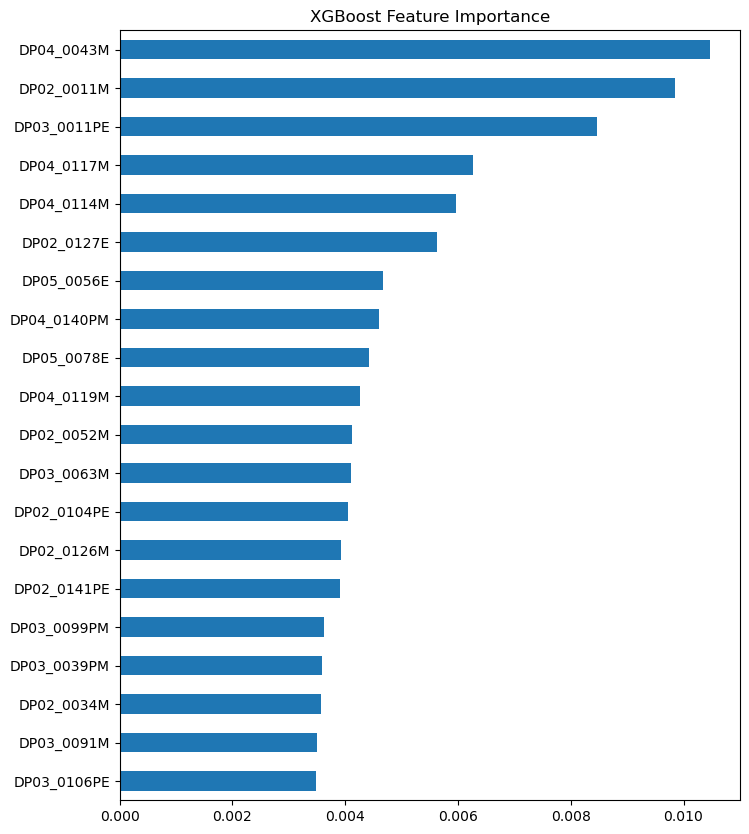

In [10]:
xgb_importances = pd.Series(
    model_xgb.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

xgb_importances.head(20).plot(kind="barh", figsize=(8,10))
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [11]:
top4_xgb = list(xgb_importances.head(4).index)
top4_rsf = list(rsf_importances.head(4).index)

print("Top 4 XGBoost features:", top4_xgb)
print("Top 4 RSF features:", top4_rsf)

Top 4 XGBoost features: ['DP04_0043M', 'DP02_0011M', 'DP03_0011PE', 'DP04_0117M']
Top 4 RSF features: ['DP02_0116M', 'DP02_0128M', 'DP03_0101E', 'DP05_0077E']


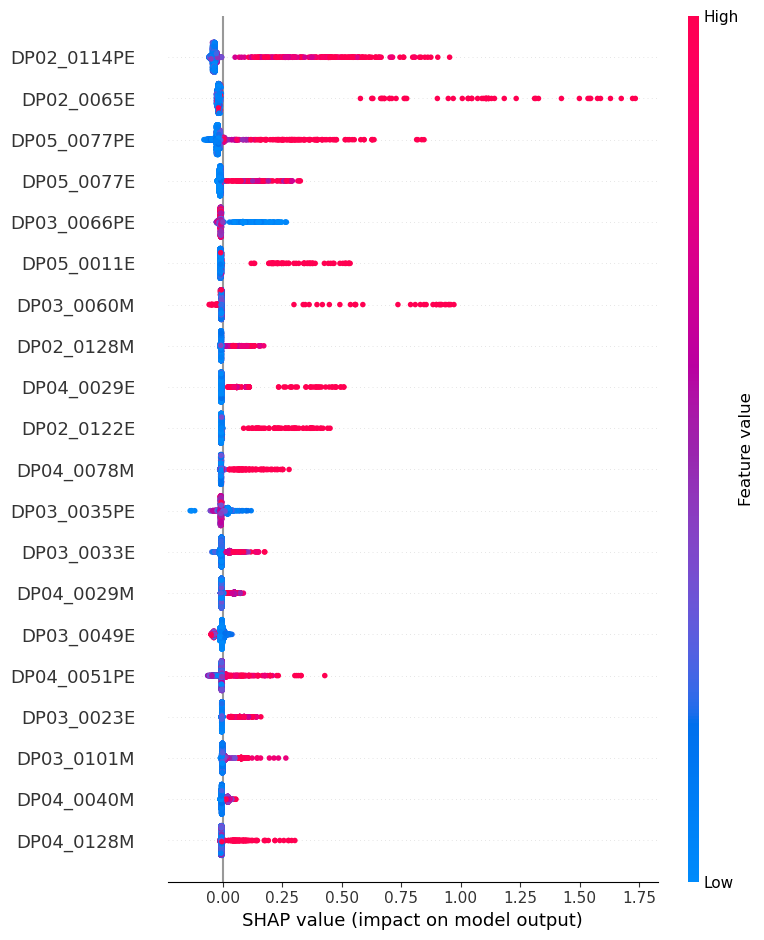

In [12]:
# fit surrogate regressor to mimic RSF (or XGB survival)
surrogate = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05
)

surrogate.fit(X_train, model_rsf.predict(X_train))

explainer = shap.TreeExplainer(surrogate)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train, max_display=20)

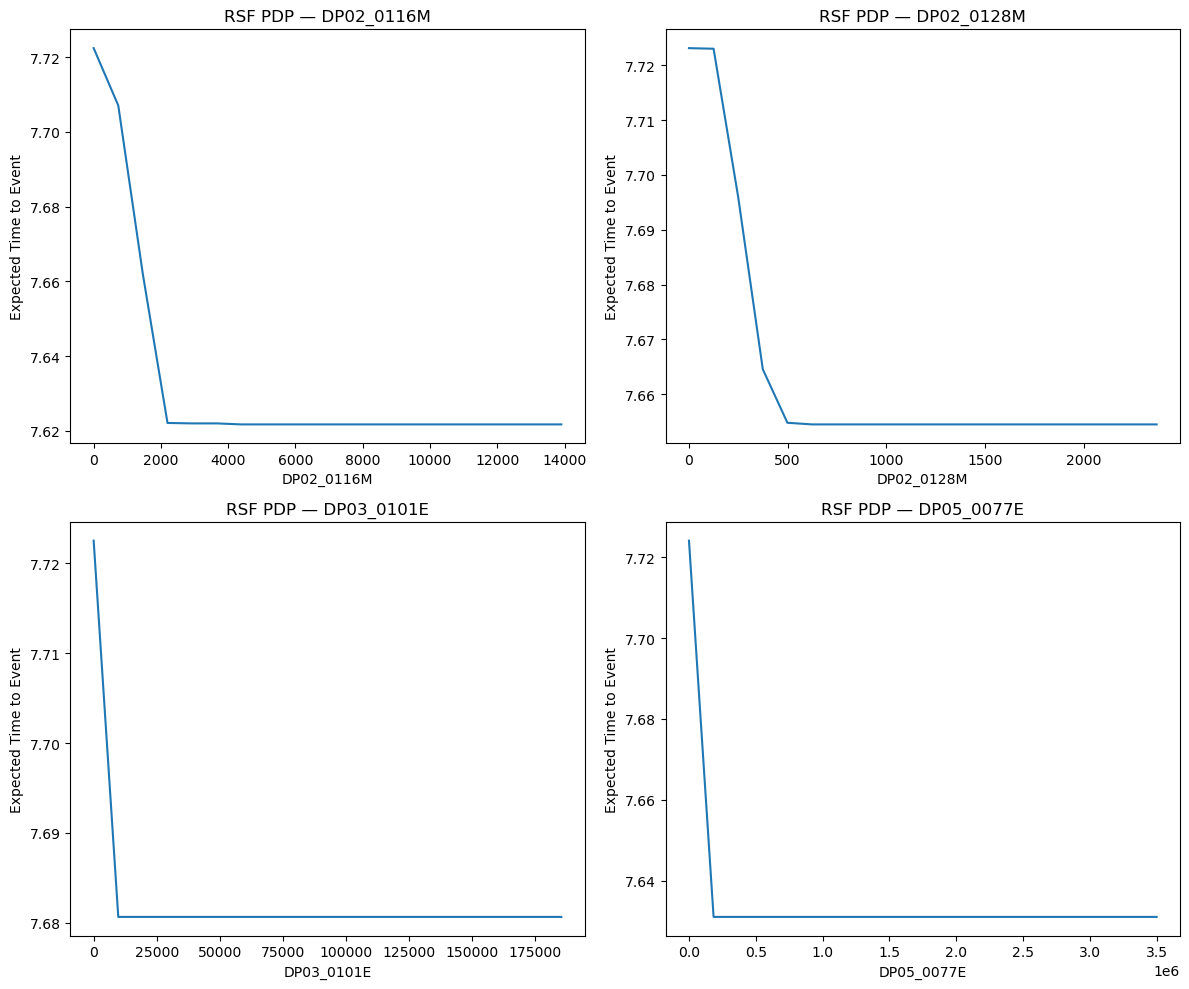

In [13]:
def predict_expected_time(model, X):
    surv_funcs = model.predict_survival_function(X)
    exp_times = np.array([np.trapz(fn.y, fn.x) for fn in surv_funcs])
    return exp_times

def partial_dependence_rsf(model, X, feature, grid_points=20):
    values = np.linspace(X[feature].min(), X[feature].max(), grid_points)
    pd_vals = []

    for v in values:
        X_temp = X.copy()
        X_temp[feature] = v
        pd_vals.append(predict_expected_time(model, X_temp).mean())

    return values, pd_vals

# Plot PDP for top 4 RSF features
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, feat in zip(axes.ravel(), top4_rsf):
    grid, pdv = partial_dependence_rsf(model_rsf, X_train, feat)
    ax.plot(grid, pdv)
    ax.set_title(f"RSF PDP — {feat}")
    ax.set_xlabel(feat)
    ax.set_ylabel("Expected Time to Event")

plt.tight_layout()
plt.show()

In [26]:
from xgboost import XGBRegressor
from sksurv.metrics import concordance_index_censored

def fit_xgb_and_cindex(X_train, X_test, y_train, y_test):
    model = XGBRegressor(
        objective="survival:cox",
        eval_metric="cox-nloglik",
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist"
    )
    model.fit(X_train, y_train["time"])
    preds = model.predict(X_test)
    
    c = concordance_index_censored(
        y_test["event"].astype(bool),
        y_test["time"].astype(float),
        preds
    )[0]
    return c


# ---------------------------------------
# 1. Baseline C-index
# ---------------------------------------
baseline_c = fit_xgb_and_cindex(X_train, X_test, y_train, y_test)
print("Baseline C-index:", baseline_c)


# ---------------------------------------
# 2. ΔC-index for TOP 4 FEATURES ONLY
# ---------------------------------------
delta_top4 = {}

for feat in top4_xgb:
    print(f"Evaluating ΔC for: {feat}")
    
    X_train_drop = X_train.drop(columns=[feat])
    X_test_drop  = X_test.drop(columns=[feat])
    
    c_drop = fit_xgb_and_cindex(X_train_drop, X_test_drop, y_train, y_test)
    delta = baseline_c - c_drop
    
    delta_top4[feat] = delta
    print(f"  ΔC-index = {delta:.4f}\n")


delta_top4_df = (
    pd.Series(delta_top4, name="delta_c")
      .sort_values(ascending=False)
      .to_frame()
)

delta_top4_df

Baseline C-index: 0.7489919741945393
Evaluating ΔC for: DP04_0043M
  ΔC-index = -0.0055

Evaluating ΔC for: DP02_0011M
  ΔC-index = 0.0091

Evaluating ΔC for: DP03_0011PE
  ΔC-index = -0.0021

Evaluating ΔC for: DP04_0117M
  ΔC-index = 0.0102



,delta_c
DP04_0117M,0.010234
DP02_0011M,0.009120
DP03_0011PE,-0.002054
DP04_0043M,-0.005549
